In [483]:
# Imports
import joblib
import numpy as np
import os

from __future__ import annotations
from common import Conf, FEATURES_PIPELINE, test_samples, training_samples, Wildcards
from dmm.initialisation import get_features, pca_transform_features
from evaluation_utils import load_model_and_obj
from penzai import pz
from util import load_petab_base_files


In [484]:
# Define conf for model you want to investigate
conf = Conf(
    model='EGFR_MAPK',  
    data="dream_cytof", 
    context="cytof_init", 
    samples="0_5", 
    features="all", 
    features_transform="pca", 
    activation_fn_name="relu", 
    optimiser="adam",
    nn_init_fn="eqx_default",
    n_hidden=2,
    depth=2,
    linear_benchmark=False,
    orth_reg_strategy="L2",
    l1reg_inflate=1e4, 
    oreg_inflate=1e2,
    l1reg_encode=1e4,
    oreg_encode=1e2,
    recon_loss=1.0,
    symm_reg=0.1,
    job=8,
    threads=1,
    reconstruct=True,
    use_simple_linear_schedule=True,
    drop_reg_after_pretrain=True,
    use_layer_bias=True,
    use_early_stopping=True,
)

In [485]:
# Define samples
samples = {
    "train": training_samples(Wildcards(conf.data, conf.samples)),
    "test": test_samples(Wildcards(conf.data, conf.samples)),
}

# Load petab_base_files
petab_base_files = load_petab_base_files(conf, reweight=True)

# Load and transform features
features = get_features(conf, datasets=['train', 'val'])
if conf.features_transform == "pca":
    # Load pre-trained pipeline if it exists
    pipeline_file = FEATURES_PIPELINE.format_map(conf.__dict__)
    if os.path.exists(pipeline_file):
        pipeline = joblib.load(FEATURES_PIPELINE.format_map(conf.__dict__))
    else:
        pipeline = None
    features = pca_transform_features(features, conf, pipeline)

In [486]:
# Display input features
pz.ts.render_array(features['train'].values)

ArrayvizRendering(html_src='<div id="arrayviz380b35fa322749759472e94ac2ec8d33" class="arrayviz_container"><span class="loading_message">Rendering array...</span></div><template class="treescope_run_soon"><script> arrayviz.buildArrayvizFigure({"destinationId": "arrayviz380b35fa322749759472e94ac2ec8d33", "info": "Dynamic colormap (click to adjust). Hover/click for array data.", "arrayBase64": "X2c/wET+tj/HH3A+pLfJv8AqJsDqWN69Za6vv3KBEb9klz6/kQgGQCv82L8/OqQ/1Glmv4TYlL/owUo/6tb9PrnKKr+SDHa/SBNwPuy0iD8EQpHAbnzVwBb82MC/ImLA3K8+v+0Ls77InYU/V6uAwHRP+r5DNgM/LdoYQMI637+N5qm/N79ZQN38GcD+udQ/K59QvofQLT/uaS7Ad6E4v6WDGr/pKPS/pPYMwMbWr7+NbFM/5sW5QNZ0qD1pi7u+NZVgPup7cr9pfZW+FStBwJ/75r9Pepy/vv//v9KAwz9HFd6/zYa+QH4bmD/5KpzAd77Vv+R2nEDixRlAC6hPPwbbkcDR8zq+Latrvzfjwz+wWLo9fnI6QGcrjL6Hz46/BZuyvhhATD+j3UVAFtfzPvtC7sD24lpA6IbbP8iQT8BLIuRAp2uwPIjpqL+4tyzA/LKRvnsCGEAkRCM/+zuSP6Yty7/a6A5AQpukP2Xpij+1Too/0V6gPtiwzT9phwhAMY1FQFpCJT/ER7s/P1FPwAzmmsCxOtO/wLKuwBPjHUD7k9e+QPgYwHDC/7+pGvw/u4QLwIKGaD8/9IW/UEQpQGBVDcDl4Ou+zLI1wWmeXb+6OoHAC5nZP5rwvb/hwa+/WcC4v/TShcAj+ZBA1muBv9W6fD+xlZY/bXTaPpXGlD2pk0JA5J36P5dW3b8vOwtABGEGwEsZxD+jSOZAPcRPwFM0+cAYuqs+eNLZv1fJ6UDKz98/HbuwQCRxiEBl6p2/NuexPy503z9cVZM/FoGbv2A+lL6QRjq+xR2iv1hBnb0vWPZAezRoP3TMLD8rBlhAO72ZvrtwtkAIEUK/zuEHv/s8o76gq+c/404qQPSu8ryA+NO+By9+wA1/AD95I7K/tDQgv5dztD8mBt0+HsudQNI+K0EtWjk/u5nmv0Fl7j/kvgfA3imWvyvrXECz6Di/yueGwPI3gD8oWeq9O7UFv71F+r6tjopAzuqTP9QgO7/smSA/GKN9P8GvA0HQopFAietOQMuGF78eEIi/gWkLQLsJHj/txbE/5U6GwJ1WCMCHjXvA+e06QEprqT+/28w/zOaNv8MV6T8S4G1AP+imP7W7LMDJkX1ApfqvQL8X8z8h7AhA4L9DPpYuoz+Ticq+seWtP8XqIcCrxvs/50CGv9ZjB8DpF0hAQ6kbv8VT9b7kGjnA79wivxQidz78k1s/n99OP5lM0kD6GtM/CmGzP5vL7j86XDvAKwyav2w/U8DqmRQ+XKy+PhMxNz+35CrAVx99v/6ZKT6gfIy/P8RFwOdxOL8HyUA/jsxxvyxMaMCQEPo/ia4Xv/GZpr/LbCdA2BZ0QFFPjsCWJ59AiIUDQD35S8DegNi/QU8ewGvk3j9Y8j5AEudMP/keyr7Xipu/fezpvhuUHL9iYVFBFbmWwBQroMByhDrA6K8zQCXclj0A5T5AGVyZPpvE2j5nV9a+I/6Pv2lWRD/tnRTACI1ov9MqRb/VCYk/VygBwJmSSj5kLzA/XrwUQQ8iLcAzOsNAINSswDH0xMChTkhALc8HwGugLsCjfe8/FF7PP4hjaL7FtQ7AnRBBwFMxYz+LvJK/muIDQIRtHr9eMeA/hmM1v9aQXMCHfYLAwefHwKRrCkCh0YZA3guxQEcLgr++6Iy/Qm9Ev0Yy6D+mMBzAsv6HvzqXN8AHHIC+qJICv7mPwb4HCfA/21bIv+n5675p5jbBz4csv10EHMD0kag/M8cMPwnkcj9lRQW/KfYwvsomJb/hbg9Ala5YwKLZAj5+MgU/gHj6v3/M9D6nvwM+mC1ev59GNL09YdK/ixVBwToHS791X/5AM7AYwE35zr/Wl0dAeWoFQfx5kL8WLqA+Wu+DwFvUDkCTRT3AxyTcvxUsG7/cISA/+o4av0m1zz9HkXi+vOXoPmkfEcF0OcK/1deHwGyOprymdeC9tuY7wLZ4NMD3nYdAOZjRPwoQHb+wPRVAtwMrwAN6JMCy4yE+1d32v3RpPL6qdFFAbEW1PY09Pr5kbPdAa8jBvjfu4D9IdzhBY+OGvnYWbL/vQCZAPTpVQFVLe0AorihAhCuXP78hMEBfAirARA42QPq5uD/MsrW/JHGvP7Zijz8Sr1K+1XDMwJ39PkD5h4/A52MfQHXzosCy8RhAf8tKP4fUwL+yneC/M74gwIUGqECNEJdAaQb0P5EHnj/imhLA304gvmLDM79E0Na/X2cCv7mZnECnXB9AbSwMQIQHk709bL5AJ9mVwCMvsr95m86/288lwCEyvL/hdU1AI74BP/CeG8ARMhO/6bBAwOqqjj/7VIO/mCDvvweJoL9y1e/ALY/ZwD8uuEAGiZM+3+1FQL7OdsDp8Fs98hkPQM+Teb+CBAI/kk2bvwCbEUDuHSM/QfDDv8vjY7+c4ho/dJ55v94yBz6dTlq+6LIhQVGoy8BpL05A0DAiwH/zrb84GoY6PTqQwIukk78VD45AZS2BwN3GpL/FFjlAB0YMvuR4oz9ixjm/RD8owIUcH79Mt9e/8URoPx27Xz/eyArA2Z0pwI6ZmEDbU1S/brzCv0iAnj4Eb54/cO0qQLIpOcB8YtC/d2gOv7UOAUBcgzzAZzELwHUzTUBmmrw/SRldP+OlRECmr4hAtGbkwDryBUAJYFO/M94NQKXahkAeT1+/jezpPxtZlT/fGxBANX+HQK+EC8ARxoBAMfF5PlSovT99Etk/wBrHPvS2JsBZXFG/v3+TQDyqLcAXTGM/LZOLvxGMfcCiwqrAw2//v0JShT+9qU7A05uaQEjgOEAnKrS/BgvZP+YHrj/80kc/oHfFP6fvST8iZww/c1UkPy9rOr1glOnA1pKgwBUAD0DzQ9q/ghczwE2OWEC8gd+/ip1mwO137L+FN9u/7KhuwIFZVT+ccJ5AruWjvknaOb9mq+G/vVpPPx1/+z5Wbf3A9rkMQRmKrTwazBBA9WSawLvxT0DGJAvAFigcPZTXtL90WNc/ERi+v3uPRj0IofO/5HifPyYMyL9mgbU/lbHfv1gKjr8dqRJADqc4wTFXvsAqKPRAzqhAv7s++D/2VaG+t8QOv+mLFb/IgIS/PKGDP53Qmb/GWExAH43gP/q+0T64tDm+/VrCv3x+Vb6BTK4/lZqoPxu5y0CMo66/apTePxnBsECGMS0/NUb7vsVNgkDL1Hy/AmIPwID9Vr+H/fK/BQ4Iv66HD7+l8IG/Q5MdQNJwqz98wtG/vAYbwNnrA78=", "arrayDtype": "float32", "validMaskBase64": "AQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBA

In [487]:
# Load model from TRAINED_BEST_MODELS file
model, obj = load_model_and_obj(conf, petab_base_files, "train")

In [488]:
# Inspect model/model components
with pz.ts.active_autovisualizer.set_scoped(pz.ts.ArrayAutovisualizer()):
  pz.ts.display(model)

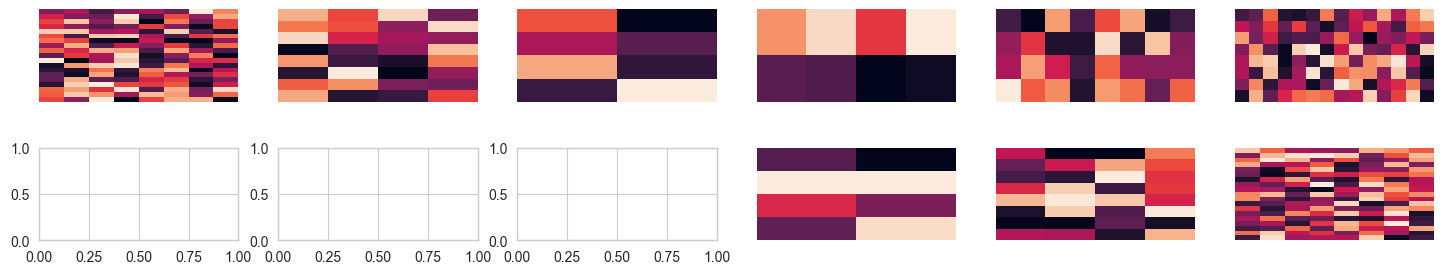

In [489]:
import seaborn as sns
import matplotlib.pyplot as plt
layers = [*model.deep_encoder.layers, *model.deep_inflater.layers]
plt.subplots(2, len(layers), figsize=(len(layers)*3, 3))
plt.subplots_adjust(hspace=0.5)
for i, layer in enumerate(layers):
    plt.subplot(2, len(layers), i+1)
    sns.heatmap(layer.weight.T, cbar=False, xticklabels=False, yticklabels=False)
for i, layer in enumerate(model.deep_decoder.layers):
    plt.subplot(2, len(layers), i+1+len(layers)+int(len(layers)/2))
    sns.heatmap(layer.weight, cbar=False, xticklabels=False, yticklabels=False)
    
plt.savefig("model_weights.svg")

Text(0.5, 1.0, 'layer 3')

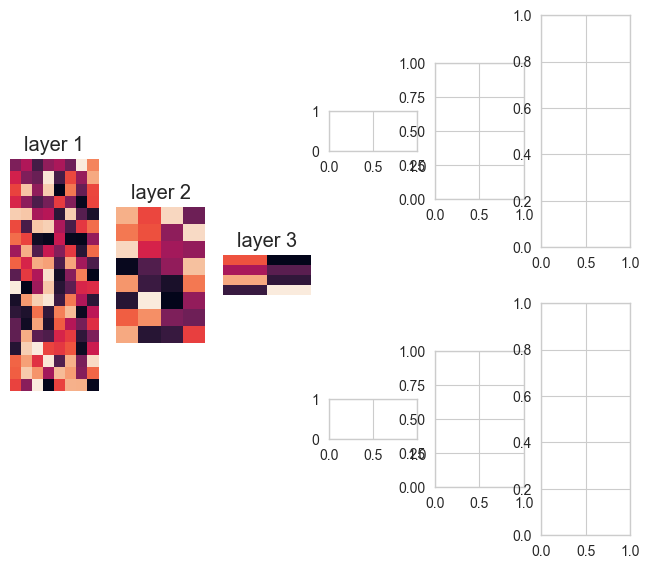

In [490]:
fig = plt.figure()
fig.set_figheight(8)
fig.set_figwidth(8)
 
# Encoder
ax1 = plt.subplot2grid(shape=(13, 6), loc=(5, 0), colspan=1, rowspan=5)
ax2 = plt.subplot2grid(shape=(13, 6), loc=(6, 1), rowspan=3)
ax3 = plt.subplot2grid(shape=(13, 6), loc=(7, 2), rowspan=1)

# Inflater
ax4 = plt.subplot2grid(shape=(13, 6), loc=(4, 3), rowspan=1)
ax5 = plt.subplot2grid(shape=(13, 6), loc=(3, 4), rowspan=3)
ax6 = plt.subplot2grid(shape=(13, 6), loc=(2, 5), colspan=1, rowspan=5)

# Decoder
ax7 = plt.subplot2grid(shape=(13, 6), loc=(10, 3), rowspan=1)
ax8 = plt.subplot2grid(shape=(13, 6), loc=(9, 4), rowspan=3)
ax9 = plt.subplot2grid(shape=(13, 6), loc=(8, 5), colspan=1, rowspan=5)
 
# plotting subplots
sns.heatmap(model.deep_encoder.layers[0].weight.T, cbar=False, xticklabels=False, yticklabels=False, ax=ax1)
ax1.set_title('layer 1')
sns.heatmap(model.deep_encoder.layers[1].weight.T, cbar=False, xticklabels=False, yticklabels=False, ax=ax2)
ax2.set_title('layer 2')
sns.heatmap(model.deep_encoder.layers[2].weight.T, cbar=False, xticklabels=False, yticklabels=False, ax=ax3)
ax3.set_title('layer 3')

In [494]:
def plot_model_weights(model, save_format="svg"): 
    num_columns = len([*model.deep_encoder.layers, *model.deep_inflater.layers]) + 2
    single_module_height = (model.module_depth)*2 + 1
    num_rows = 2*single_module_height + 3
    
    fig = plt.figure()
    fig.set_figheight(num_rows)
    fig.set_figwidth(num_columns)
    
    # Plot input - features
    ax = plt.subplot2grid(
            shape=(num_rows, num_columns), 
            loc=(int(num_rows/2)-len(model.deep_encoder.layers)+1, 0), 
            colspan=1, 
            rowspan=single_module_height
        )
    sns.heatmap(
        np.zeros(shape=(model.deep_encoder.layers[0].weight.T.shape[0], 1)), 
        cbar=False, xticklabels=False, yticklabels=False, ax=ax
    )
    ax.set_title(f"in: {model.deep_encoder.layers[0].weight.T.shape[0]}")
    for i, layer in enumerate(model.deep_encoder.layers[::-1]):
        ax = plt.subplot2grid(
            shape=(num_rows, num_columns), 
            loc=(int(num_rows/2)-i, len(model.deep_encoder.layers)-i), 
            colspan=1, 
            rowspan=1+2*i
        )
        sns.heatmap(layer.weight.T, cbar=False, xticklabels=False, yticklabels=False, ax=ax)
        ax.set_title(f"e.{i}: {layer.weight.T.shape}")
        
    # Plot output - kinetic parameters
    ax = plt.subplot2grid(
            shape=(num_rows, num_columns), 
            loc=(0, num_columns-1), 
            colspan=1, 
            rowspan=single_module_height
        )
    sns.heatmap(
        np.zeros(shape=(model.deep_inflater.layers[-1].weight.T.shape[0], 1)), 
        cbar=False, xticklabels=False, yticklabels=False, ax=ax
    )
    ax.set_title(f"out: {model.deep_inflater.layers[-1].weight.shape[0]}")
    
    for i, layer in enumerate(model.deep_inflater.layers[::-1]):
        ax = plt.subplot2grid(
            shape=(num_rows, num_columns), 
            loc=(i, num_columns-2-i), 
            colspan=1, 
            rowspan=single_module_height-2*i
        )
        sns.heatmap(layer.weight.T, cbar=False, xticklabels=False, yticklabels=False, ax=ax)
        ax.set_title(f"i.{len(model.deep_inflater.layers)-i}: {layer.weight.T.shape}")
        
    if model.reconstruct: 
        # Plot input - features
        ax = plt.subplot2grid(
                shape=(num_rows, num_columns), 
                loc=(2+int(num_rows/2), num_columns-1), 
                colspan=1, 
                rowspan=single_module_height
            )
        sns.heatmap(
            np.zeros(shape=(model.deep_encoder.layers[0].weight.T.shape[0], 1)), 
            cbar=False, xticklabels=False, yticklabels=False, ax=ax
        )
        ax.set_title(r"$\rm \widehat{in}$:" + str(model.deep_encoder.layers[0].weight.T.shape[0]))
        
        for i, layer in enumerate(model.deep_decoder.layers[::-1]):
            ax = plt.subplot2grid(
                shape=(num_rows, num_columns), 
                loc=(num_rows-single_module_height+i, num_columns-2-i), 
                colspan=1, 
                rowspan=single_module_height-2*i
            )
            sns.heatmap(layer.weight, cbar=False, xticklabels=False, yticklabels=False, ax=ax)
            ax.set_title(f"d.{len(model.deep_decoder.layers)-i}: {layer.weight.T.shape}")
    
    if save_format is not None:
        plt.savefig(f"model_weights.{save_format}", facecolor='w')
    plt.show()
    
    
    

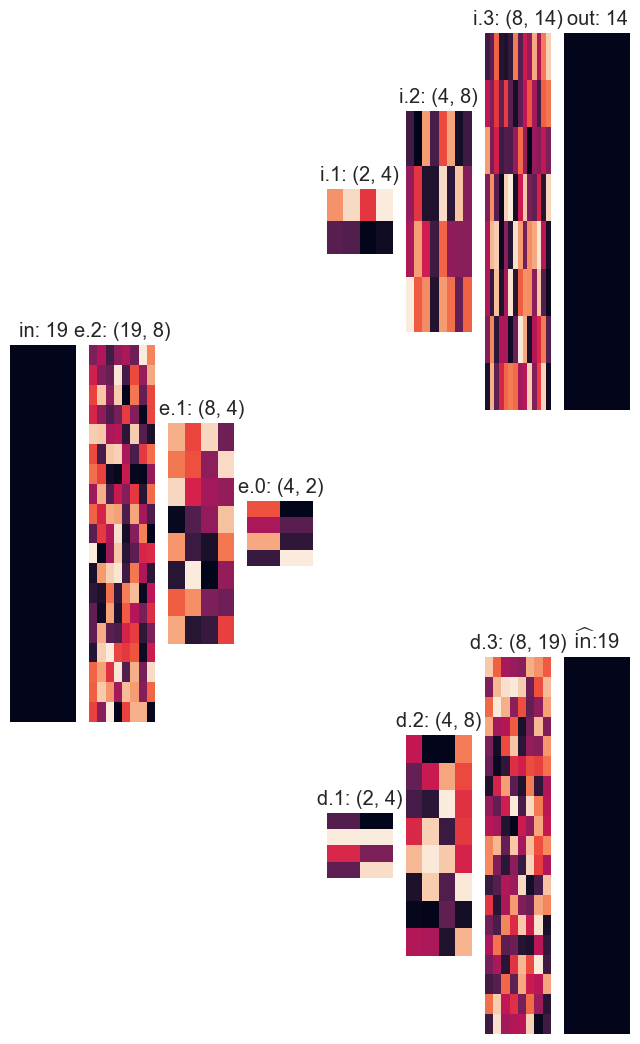

In [495]:
plot_model_weights(model)

In [496]:
from dmm.initialisation import setup_models

conf2 = conf
conf2.depth = 4
model2, _ = setup_models(conf2, petab_base_files, 'train')

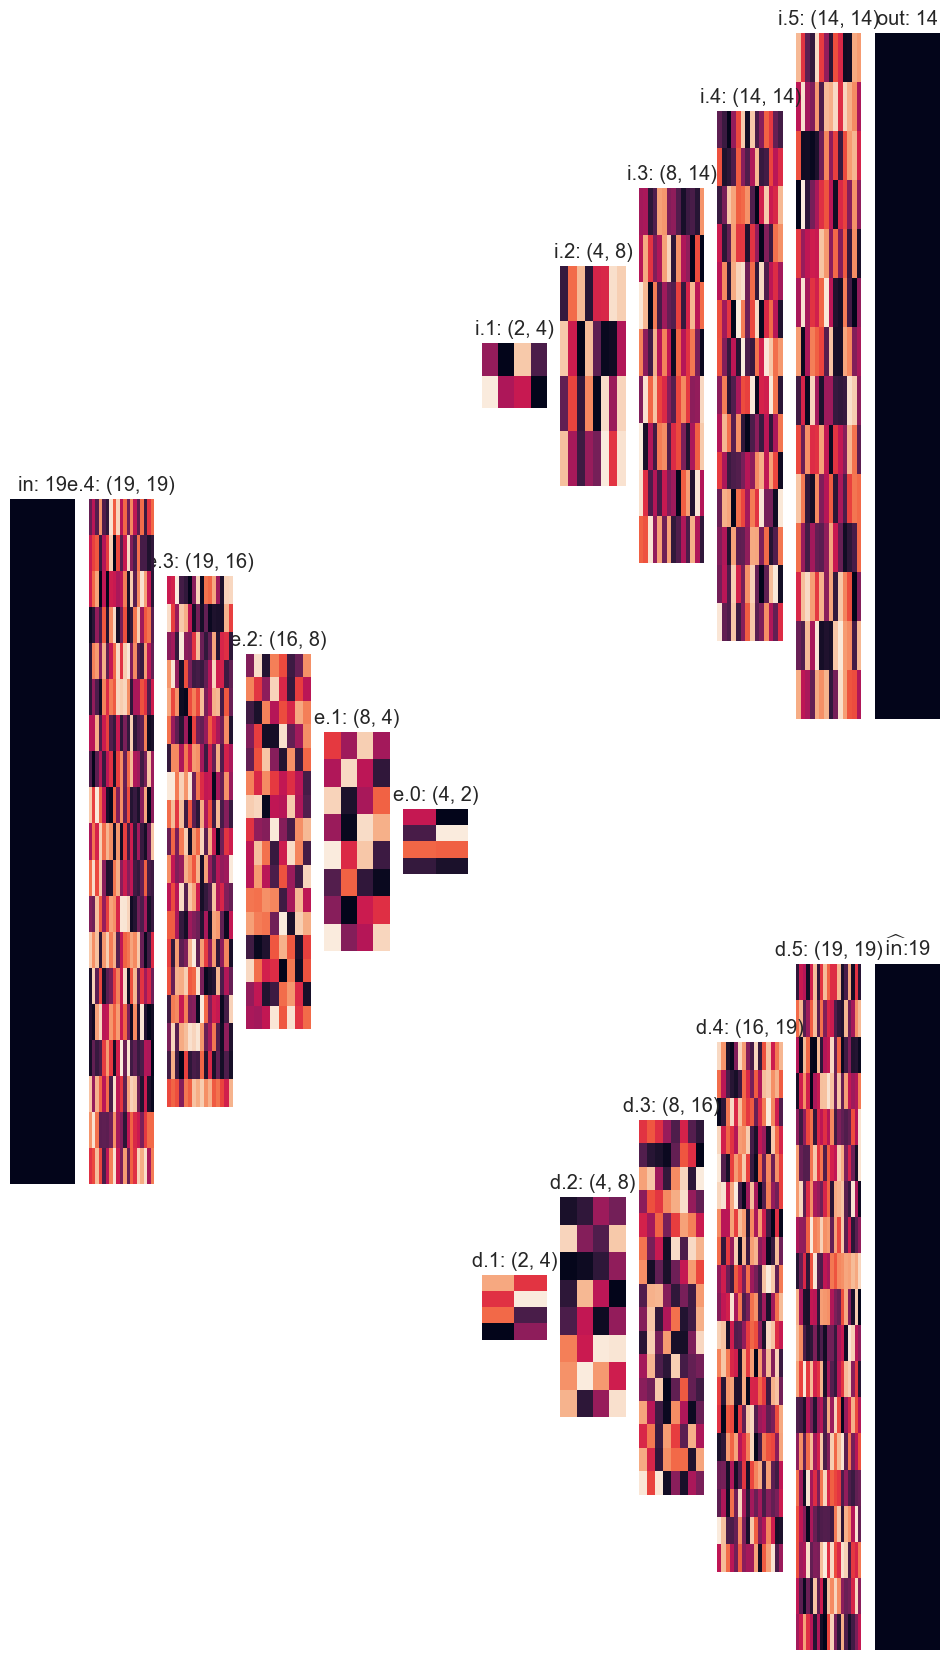

In [497]:
plot_model_weights(model2, save_format=None)